<a href="https://colab.research.google.com/github/yuniecorn-dev/esaa_assignment/blob/main/YB_0522_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C_%EC%B0%A8%EC%9B%90%EC%B6%95%EC%86%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 데이터 로드
from sklearn.datasets import fetch_openml
mnist=fetch_openml('mnist_784', version=1)

In [2]:
# train, test split
X_train = mnist['data'][:60000]
y_train = mnist['target'][:60000]
X_test = mnist['data'][60000:]
y_test = mnist['target'][60000:]

* 랜덤포레스트에 적용

In [3]:
# 랜덤포레스트에 적용 (n_estimators=10, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_clf = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [4]:
# 정확도 결과
y_pred = rf_clf.predict(X_test)
print(f"원본 데이터 세트 정확도: {accuracy_score(y_test, y_pred):.4f}")

원본 데이터 세트 정확도: 0.9492


# 1. PCA

* PCA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [5]:
# PCA 라이브러리 불러오기
from sklearn.decomposition import PCA

In [6]:
# PCA 적용 95% : n_components=0.95
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)

In [7]:
# PCA 이후 랜덤포레스트 훈련
rf_clf_pca = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_pca.fit(X_train_pca, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [8]:
# 정확도 결과 (X_test도 PCA 적용해야합니다.)
X_test_pca = pca.transform(X_test)
y_pred_pca = rf_clf_pca.predict(X_test_pca)
print(f"PCA 적용 후 정확도: {accuracy_score(y_test, y_pred_pca):.4f}")

PCA 적용 후 정확도: 0.8925


**관련 문제**

* PCA모델을 와인 데이터셋에 적용하여 차원을 축소하고 그 결과를 그래프로 나타내보세요.

(1) 필요한 모듈 불러오기

In [9]:
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

(2)  load_wine을 사용해 데이터셋을 생성한다.

In [10]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

(3) X에 표준 스케일링(Standard scaling)을 적용하여 X_scaled을 생성한다.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_wine)

(4) PCA 모델을 X에 적용하여 2개의 차원으로 추출한다. 단, random_state=1234로 설정한다.

In [12]:
#PCA 모델을 X_scaled에 적용하여 2개의 차원으로 추출한다.
pca_wine = PCA(n_components=2, random_state=1234)
X_pca_wine = pca_wine.fit_transform(X_scaled)

(5) 추출한 피처를 그래프로 나타내라.

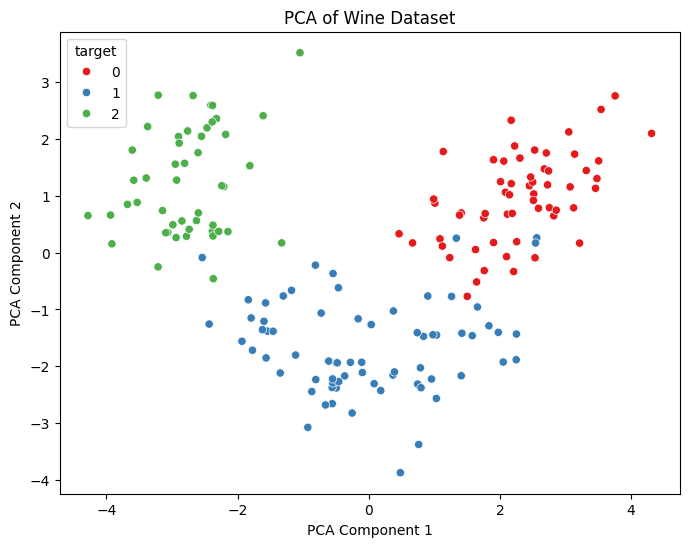

In [13]:
# 데이터프레임으로 변환
pca_columns = ['pca_component_1', 'pca_component_2']
wine_df_pca = pd.DataFrame(X_pca_wine, columns=pca_columns)
wine_df_pca['target'] = y_wine

# seaborn을 이용한 산점도 그래프 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(x='pca_component_1', y='pca_component_2', hue='target', palette='Set1', data=wine_df_pca)
plt.title('PCA of Wine Dataset')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

# 2. LDA

- LDA로 변환한 데이터 세트에 랜덤 포레스트 적용

In [14]:
# LDA 라이브러리 불러오기
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [15]:
# LDA 적용 : n_components=5
lda = LinearDiscriminantAnalysis(n_components=5)
X_train_lda = lda.fit_transform(X_train, y_train)

In [16]:
# LDA 이후 랜덤포레스트 훈련
rf_clf_lda = RandomForestClassifier(n_estimators=10, random_state=42)
rf_clf_lda.fit(X_train_lda, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [17]:
# 정확도 결과 (X_test도 LDA 적용해야합니다.)
X_test_lda = lda.transform(X_test)
y_pred_lda = rf_clf_lda.predict(X_test_lda)
print(f"LDA 적용 후 정확도: {accuracy_score(y_test, y_pred_lda):.4f}")

LDA 적용 후 정확도: 0.8301
